# 1. Calculate all distances
### pc4 approach
- (46,870,226 million edges): 6 seconds
### ttwa -> 5km filter
- Pre-filtered 33,476 valid TTWA pairs for BVH optimization.
- Pre-filtered 2,469,332 valid PC4 pairs for BVH optimization.
- Joined maximum 17,604,401,146 firm pairs for distance calculation.
- Materializing sparse distance matrix (filtered to <= 5.0km using BVH) out-of-core...
- 🎉 SUCCESS! Total edges calculated: 734,346,954 (48m)

In [ ]:
import ibis
from ibis import _
import pandas as pd
from utils.f_0_dirs import get_data_dirs
from f_5_distances import compute_distance_matrix

table_in_name = "working_fixed"
table_out_name = "working_distance"

# ==========================================
# 1. SETUP & EXTENSION LOADING
# ==========================================
dirs = get_data_dirs()
print("⏳ Initializing DuckDB connection and loading spatial extension...")
start_time = pd.Timestamp.now()
con = ibis.duckdb.connect(dirs.db_path)
con.raw_sql("INSTALL spatial; LOAD spatial;")
print(f"✅ Database connected in {(pd.Timestamp.now() - start_time).total_seconds():.1f} seconds.")


⏳ Initializing DuckDB connection and loading spatial extension...
✅ Database connected in 0.6 seconds.


In [ ]:
con.raw_sql("INSTALL spatial; LOAD spatial;")    
t: ibis.Table = con.table(table_in_name)

# Ibis ORM: Filter valid coordinates and required group columns
t_clean = t.filter([
    t.lon_dec.notnull() & (t.lon_dec != 0),
    t.lat_dec.notnull() & (t.lat_dec != 0),
    t.ttwa.notnull(),
    t.pc4.notnull(),
    t.pc8.notnull()
]).select(["registered_number", "lon_dec", "lat_dec", "pc4", "ttwa", "pc8"])
con.create_view("view_t_clean", t_clean, overwrite=True)
prelim_centroids = (
    t_clean
    .group_by('pc4')
    .aggregate(
        prelim_lon=_.lon_dec.mean(), 
        prelim_lat=_.lat_dec.mean()
    )
)
con.create_view("view_prelim_centroids", prelim_centroids, overwrite=True)

# Create a table for each pc4 postcode with the following columns:
# Number of firms in postcode, mean distance to centroid, max distance to centroid, 95th quantile distance to centroid, number of firms outside 95th quantile
# Number of firms outside 5000 metres away from centroid.
query_outliers = """--sql
    SELECT
        f.pc4,
        COUNT(*) AS num_firms,
        AVG(ST_Distance_Sphere(ST_Point(f.lon_dec, f.lat_dec), ST_Point(c.prelim_lon, c.prelim_lat))) AS mean_distance_to_centroid,
        MAX(ST_Distance_Sphere(ST_Point(f.lon_dec, f.lat_dec), ST_Point(c.prelim_lon, c.prelim_lat))) AS max_distance_to_centroid,
        PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY ST_Distance_Sphere(ST_Point(f.lon_dec, f.lat_dec), ST_Point(c.prelim_lon, c.prelim_lat))) AS p95_distance_to_centroid,
        SUM(CASE WHEN ST_Distance_Sphere(ST_Point(f.lon_dec, f.lat_dec), ST_Point(c.prelim_lon, c.prelim_lat)) > 5000 THEN 1 ELSE 0 END) AS num_firms_outside_5000m
    FROM view_t_clean f
    JOIN view_prelim_centroids c ON f.pc4 = c.pc4
    GROUP BY f.pc4
"""
df_outliers = con.sql(query_outliers).execute()
df_sorted = df_outliers.sort_values(by="num_firms_outside_5000m", ascending=False)
display(df_sorted)

,pc4,num_firms,mean_distance_to_centroid,max_distance_to_centroid,p95_distance_to_centroid,num_firms_outside_5000m
186,LS1,1621,19917.724933,401383.616346,50590.720640,1621
2352,EC4A,1386,11158.657752,335888.076485,7602.093543,1223
2453,M2,1200,16277.920814,354077.491785,49423.782855,1200
2521,EC2A,1087,15680.886735,304144.883343,8718.938662,1068
912,B3,1056,14421.538682,351002.707599,43297.269256,1055
...,...,...,...,...,...,...
2170,EH26,14,1432.465095,3429.194376,3256.259517,0
2171,EH35,2,0.000000,0.000000,0.000000,0
1490,IV43,1,0.000000,0.000000,0.000000,0
497,ZE1,29,1295.471901,2476.198183,2458.176564,0


In [5]:
# ==========================================
# 4. EXECUTION and VERIFICATION
# ==========================================
dist_matrix = compute_distance_matrix(con, table_in_name, table_out_name,
                                      prop_col="ttwa", max_distance=5000, bind_by_box=True)
print(f"🎉 SUCCESS! Total edges calculated: {dist_matrix.count().execute():,}")
# Optional: Peek at the data
display(con.table("working_distance").head(5).execute())

('registered_number', 'lon_dec', 'lat_dec', 'pc4', 'ttwa', 'pc8')
--- Pre-filtered 33,476 valid TTWA pairs for BVH optimization.
--- Pre-filtered 2,469,332 valid PC4 pairs for BVH optimization.
--- Schema of 'view_valid_pc4_pairs': ibis.Schema {
  pc4_a  string
  pc4_b  string
}
--- Joined maximum 17,604,401,146 firm pairs for distance calculation.
--- Materializing sparse distance matrix (filtered to <= 5.0km using BVH) out-of-core...
🎉 SUCCESS! Total edges calculated: 734,346,954


,firm_i,firm_j,distance_meters
0,02185448,02838541,1938.809375
1,02425634,02838541,1802.723825
2,00541295,02838541,1918.306212
3,02461547,02838541,1802.723825
4,04396922,02838541,1938.809375


In [10]:
# Print working_distance table schema for verification
print("Schema of working_distance table:")
print(con.table("working_distance").schema())
print(f"Count of rows in working_distance table: {con.table('working_distance').count().execute():,}")

Schema of working_distance table:
ibis.Schema {
  firm_i           string
  firm_j           string
  distance_meters  float64
}
Count of rows in working_distance table: 734,346,954


# 2. [read] summary stats: generated distances table

In [2]:
import ibis
from ibis import _
from utils.f_0_dirs import get_data_dirs

table_in_name = "working_fixed"
table_out_name = "working_distance_ttwa_km"

dirs = get_data_dirs(segment="calculations")
con = ibis.duckdb.connect(dirs.db_path)
table_out = con.table(table_out_name)
table_fixed = con.table(table_in_name).select("registered_number", "pc8", "lat_lon5", "address_lvl", "address_case")
tf_i = table_fixed.alias("tf_i")
tf_j = table_fixed.alias("tf_j")

# 3. Perform double left join and explicitly select/rename columns
table_joined = (
    table_out
    .left_join(tf_i, table_out.firm_i == tf_i.registered_number)
    .rename({f"{col}_i": f"{col}" for col in tf_i.columns})
    .left_join(tf_j, table_out.firm_j == tf_j.registered_number)
    .rename({f"{col}_j": f"{col}" for col in tf_j.columns})
)

# # Display sample of 500 random rows
# table_sample = table_joined.sample(10 / table_joined.count().execute()).execute()
# display(table_sample)

# # Show largest 50 distances
# table_largest = table_joined.order_by(table_joined.distance_meters.desc()).limit(10).execute()
# display(table_largest)

### range/shape statistics

In [3]:
import ibis
from ibis import _

# Assuming connection is still active: con = ibis.duckdb.connect(db_path)
dist_matrix = con.table("working_distance_ttwa_km")
working_fixed = con.table("working_fixed")

print("⏳ Calculating summary statistics for 13M rows...")

# 1. Aggregate distance distributions
summary_stats = dist_matrix.aggregate(
    total_edges = dist_matrix.distance_meters.count(),
    min_distance = dist_matrix.distance_meters.min(),
    avg_distance = dist_matrix.distance_meters.mean(),
    median_distance = dist_matrix.distance_meters.approx_median(),
    quantile_95 = dist_matrix.distance_meters.approx_quantile(0.95),
    max_distance = dist_matrix.distance_meters.max()
).execute()

sum2 = (
    dist_matrix
    .group_by("firm_i")
    .aggregate(nb_peers=_.count())
    .mutate(
        avg_nb_peers = _.nb_peers.mean(),
        q95_nb_peers = _.nb_peers.approx_quantile(0.95),
        max_nb_peers = _.nb_peers.max(),
    )
).execute()

# Print human-readable output
print("\n=== SPATIAL MATRIX HEALTH CHECK ===")
print(f"Total Peer Connections:     {summary_stats['total_edges'][0]:,}")
print(f"Minimum Distance:           {summary_stats['min_distance'][0]:,.0f} meters")  # Expect ~0 for firms in same building
print(f"Median Distance:            {summary_stats['median_distance'][0]:,.0f} meters")
print(f"Mean Distance:              {summary_stats['avg_distance'][0]:,.0f} meters")
print(f"95th Percentile Distance:   {summary_stats['quantile_95'][0]:,.0f} meters")
print(f"Maximum Distance:           {summary_stats['max_distance'][0]:,.0f} meters")  # Should not exceed UK PC4 bounds (usually < 20km)
print(f"Average Number of Peers:    {sum2['avg_nb_peers'][0]:.2f}")
print(f"95th Percentile Number of Peers: {sum2['q95_nb_peers'][0]:,.0f}")
print(f"Maximum Number of Peers:    {sum2['max_nb_peers'][0]:,}")

# 2. Check for isolated firms (Firms that were the only one in their pc4)
isolated_count = working_fixed.anti_join(dist_matrix, working_fixed.registered_number == dist_matrix.firm_i).count().execute()

print(f"Isolated Firms (0 peers): {isolated_count:,}")

⏳ Calculating summary statistics for 13M rows...


RuntimeError: Query interrupted

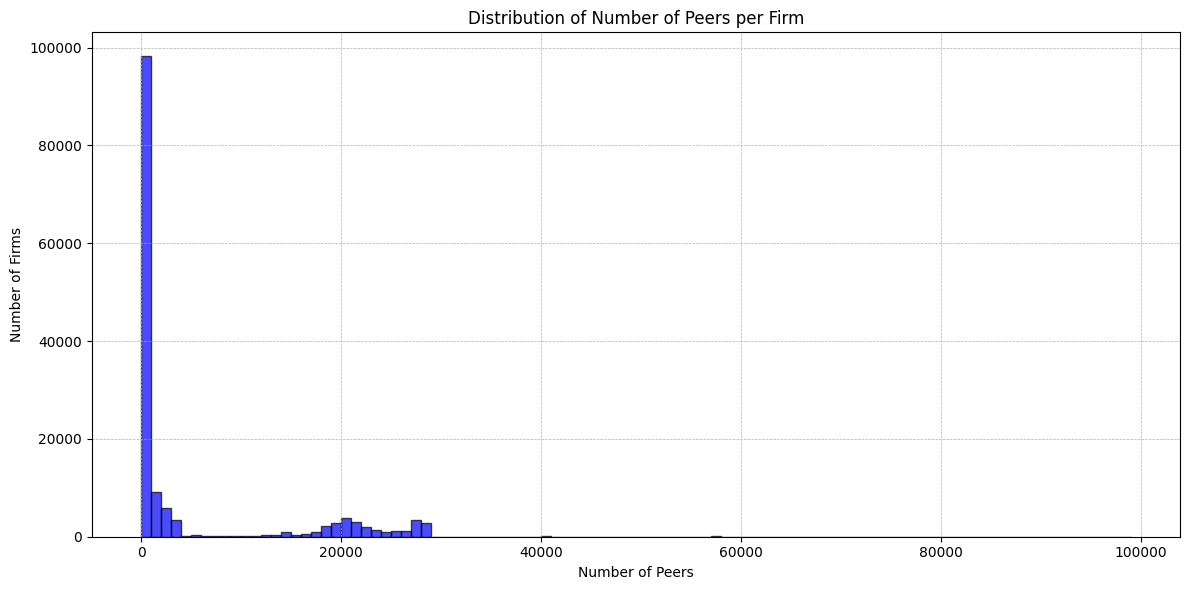

In [23]:
# Generate a histogram showing the number of peers per firm
# Group by firm_i and count the number of peers (firm_j) for each firm_i
# Group by firm_j and count the number of peers (firm_i) for each firm_j
# Sum then together for each firm to get total number of peers
import matplotlib.pyplot as plt

peer_counts_i = dist_matrix.group_by("firm_i").aggregate(num_peers_i=_.count())
peer_histogram = peer_counts_i.execute()

plt.figure(figsize=(12, 6))
plt.hist(peer_histogram['num_peers_i'], bins=range(0, 100000, 1000), alpha=0.7, color='blue', edgecolor='black')
plt.title("Distribution of Number of Peers per Firm")
plt.xlabel("Number of Peers")
plt.ylabel("Number of Firms")
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

In [6]:
run_filtering = True  # Set to False to skip filtering and summary statistics
if run_filtering:
    out_table_name_2 = "working_distance_filtered"

    # Drop all distances which are larger than 20km.
    # These will have a very weak effect in the regresssion anyway since we use a distance decay function.
    filtered_matrix = dist_matrix.filter(dist_matrix.distance_meters <= 20000)

    con.create_table(out_table_name_2, filtered_matrix, overwrite=True)
    filtered_matrix = con.table(out_table_name_2)

    print(f"⏳ Calculating summary statistics for {filtered_matrix.count().execute():,} rows (Out-of-Core)...")

    # 1. Aggregate distance distributions
    summary_stats = filtered_matrix.aggregate(
        total_edges = filtered_matrix.distance_meters.count(),
        min_distance = filtered_matrix.distance_meters.min(),
        avg_distance = filtered_matrix.distance_meters.mean(),
        median_distance = filtered_matrix.distance_meters.approx_median(),
        quantile_95 = filtered_matrix.distance_meters.approx_quantile(0.95),
        max_distance = filtered_matrix.distance_meters.max()
    ).execute()

    # Print human-readable output
    print("\n=== SPATIAL MATRIX HEALTH CHECK ===")
    print(f"Total Peer Connections: {summary_stats['total_edges'][0]:,}")
    print(f"Minimum Distance:       {summary_stats['min_distance'][0]:,.0f} meters")  # Expect ~0 for firms in same building
    print(f"Median Distance:        {summary_stats['median_distance'][0]:,.0f} meters")
    print(f"Mean Distance:          {summary_stats['avg_distance'][0]:,.0f} meters")
    print(f"95th Percentile Distance: {summary_stats['quantile_95'][0]:,.0f} meters")
    print(f"Maximum Distance:       {summary_stats['max_distance'][0]:,.0f} meters")  # Should not exceed UK PC4 bounds (usually < 20km)

    # 2. Check for isolated firms (Firms that were the only one in their pc4)
    isolated_count = working_fixed.anti_join(filtered_matrix, working_fixed.registered_number == filtered_matrix.firm_i).count().execute()

    print(f"Isolated Firms (0 peers): {isolated_count:,}")

⏳ Calculating summary statistics for 43,241,404 rows (Out-of-Core)...

=== SPATIAL MATRIX HEALTH CHECK ===
Total Peer Connections: 43,241,404
Minimum Distance:       0 meters
Median Distance:        655 meters
Mean Distance:          1,625 meters
95th Percentile Distance: 6,782 meters
Maximum Distance:       20,000 meters
Isolated Firms (0 peers): 3,365


In [7]:
# ==========================================
# CELL 2: SINGLE FIRM "EGO-NETWORK" PREVIEW (PURE IBIS)
# ==========================================
# Assume connections exist
working_fixed = con.table("working_fixed")
dist_matrix = con.table("working_distance_filtered")

# 1. Pick a random firm that has a decent number of peers (20 to 50)
target_firm_expr = (
    dist_matrix
    .group_by(['firm_i', 'pc4'])
    .agg(peer_count=dist_matrix.firm_j.count())
    .filter(lambda t: (t.peer_count >= 20) & (t.peer_count <= 50))
    .limit(1)
)

target_info = target_firm_expr.execute()
target_firm_id = target_info['firm_i'].iloc[0]
target_pc4 = target_info['pc4'].iloc[0]

print(f"Examining Firm: {target_firm_id} (Postcode Sector: {target_pc4})")
print(f"Total peers in sector: {target_info['peer_count'].iloc[0]}")

# 2. Pull this specific firm's network using Ibis Joins
# First, filter the 13M row matrix down to just the ~30 rows for our target firm
ego_edges = dist_matrix.filter(dist_matrix.firm_i == target_firm_id)

# Setup aliases so we can join the working_fixed table to itself twice
w1 = working_fixed.alias("w1") # For the Target Firm's coordinates

Examining Firm: 09896672 (Postcode Sector: IP30)
Total peers in sector: 34


In [ ]:
check_cases = [
    ["07033866", "11656092"],
    ["07033866", "04487275"],
]

# 3. Plot some maps of the firms

In [2]:
import ibis
from utils.f_0_dirs import get_data_dirs
from f_5_distances import compute_distance_matrix, join_fd_tables, plot_folium_network

exclude_london = True
fixed_table_name = "working_fixed"
distance_table_name = "working_distance_ttwa_km"

# ----

dirs = get_data_dirs(segment="calculations")
con = ibis.duckdb.connect(dirs.db_path)
working_fixed = con.table(fixed_table_name)
dist_matrix = con.table(distance_table_name)

working_fixed_skinny = working_fixed.select("registered_number", "ttwa", "pc8", "lat_dec", "lon_dec")
# ref_ttwa = con.table("ttwa")
ref_ttwa = con.read_csv(dirs.input_dir / "TTWA Travel to Work Area names and codes UK as at 12_11 v5.csv")

# 1. Logic to find initial node. Don't use otherwise
dist_matrix_gr = (
    dist_matrix
    .group_by('firm_i')
    .agg(peer_count=dist_matrix.firm_j.count())
    .filter(lambda t: t.peer_count >= 10)  # Just ensuring they aren't isolated
)
if exclude_london:
    dist_matrix_gr_filtered = (
        dist_matrix_gr
        .inner_join(working_fixed_skinny, dist_matrix_gr.firm_i == working_fixed_skinny.registered_number)
        .inner_join(ref_ttwa, ibis._.ttwa == ref_ttwa.TTWA11CD)
        .filter(ibis._.TTWA11NM != 'London')
    )
else:
    dist_matrix_gr_filtered = dist_matrix_gr

In [10]:
# --- USER VARIABLES ---
sample_nb_firms = 10
include_firms = ["03140144"]

print(f"⏳ Sampling {sample_nb_firms} firms and generating networks...")

# 2. Sample the IDs. (We add .limit() because .sample() is approximate and might return 6)
start_table = (
    dist_matrix_gr_filtered
    .order_by(ibis.random())  # type: ignore
    .limit(sample_nb_firms)
)
if include_firms:
    include_expr = dist_matrix_gr_filtered.filter(dist_matrix_gr_filtered.firm_i.isin(include_firms))
    start_table = start_table.union(include_expr).distinct()

total_df_hydrated = (
    start_table
    .select("firm_i")
    .inner_join(working_fixed_skinny, start_table.firm_i == working_fixed_skinny.registered_number)
    .inner_join(ref_ttwa, ibis._.ttwa == ref_ttwa.TTWA11CD)
    .execute()
)

target_ids = total_df_hydrated['firm_i'].tolist()
print(f"🎯 Selected Target Firms: {target_ids}")

# 3. Fetch data using our reusable function
df_multi_query: ibis.Table = join_fd_tables(working_fixed_skinny, dist_matrix, i_name="target", j_name="peer", filter_ids=target_ids)
df_multi_network = df_multi_query.execute()
# For every row in hydrated, print its ttwa and number of peers fetched
for row in total_df_hydrated.itertuples():
    target_id = row.firm_i
    peer_count = len(df_multi_network[df_multi_network['firm_target'] == target_id])
    print(f"✅ Fetched {peer_count:,} edges for target firm {target_id} in {row.TTWA11NM}.")

# 4. Generate and display the map using our reusable function
network_map = plot_folium_network(df_multi_network)

# 5. Display network_map in out_dir as an html
out_path = dirs.output_dir / "ego_network_map.html"
print(f"⏳ Saving ego-network map to {out_path}")
network_map.save(out_path)

⏳ Sampling 10 firms and generating networks...
🎯 Selected Target Firms: ['03898489', '06396714', '03003875', 'NI668323', '03639689', '01409833', '02062057', 'SC136348', '01409833', '04175952', '05071288']
✅ Fetched 186 edges for target firm 03898489 in Darlington.
✅ Fetched 3324 edges for target firm 06396714 in Manchester.
✅ Fetched 139 edges for target firm 03003875 in Burton upon Trent.
✅ Fetched 16 edges for target firm NI668323 in Enniskillen.
✅ Fetched 244 edges for target firm 03639689 in Chelmsford.
✅ Fetched 10016 edges for target firm 01409833 in Leeds.
✅ Fetched 37 edges for target firm 02062057 in Mansfield.
✅ Fetched 1696 edges for target firm SC136348 in Glasgow.
✅ Fetched 10016 edges for target firm 01409833 in Leeds.
✅ Fetched 2686 edges for target firm 04175952 in Birmingham.
✅ Fetched 398 edges for target firm 05071288 in Slough and Heathrow.
⏳ Saving ego-network map to C:\Users\lazyst\Files\ucl\Dissertation\calculations\output\ego_network_map.html


### Explosive non-overlapping networks

In [3]:
import ibis
from ibis import _
import pandas as pd

max_depth = 4
max_peers = 3

# 1. Establish the original firm and its coordinates
start_df = (
    dist_matrix_gr_filtered
    .order_by(ibis.random())  # type: ignore
    .limit(1)
    .select("firm_i")
    .execute()
)

orig_id = start_df['firm_i'].iloc[0]
id_d_list: list[list[str]] = [[orig_id]]

for i in range(max_depth):

    all_target_ids = [id for sublist in id_d_list for id in sublist]
    latest_target_ids = id_d_list[-1]

    print(f"🎯 Depth {i}: Fetching peers for target firms: {latest_target_ids}")
    
    # 2. Fetch peers of current target_ids from the precomputed global matrix
    # With our filtering, firm_target is guaranteed to be in latest_target_ids, and firm_peer is guaranteed to NOT be in all_target_ids
    table_new_peers: ibis.Table = join_fd_tables(working_fixed_skinny, dist_matrix, i_name="target", j_name="peer", filter_ids=latest_target_ids)
    table_new_peers_f = (
        table_new_peers.filter(
            ~(table_new_peers.firm_peer.isin(all_target_ids)) &
            (table_new_peers.distance_meters != 0)
        )
        .distinct(on="firm_peer")
        .order_by(ibis.random())        # type: ignore
    )

    # 3. Select 5 furthest peers from the original node
    # 3a. Depth 1: Just take the 5 furthest from the original node
    if i == 0:
        df_select_peers = table_new_peers_f.limit(max_peers).execute()

    # 3b. Depth > 1: We must evaluate the distance of these new peers back to the ORIGINAL node
    else:

        con.create_view("temp_random_peers", table_new_peers_f.limit(10 * max_peers * len(latest_target_ids)), overwrite=True)
        df_new_peers_short = con.table("temp_random_peers")
        list_new_peers = df_new_peers_short.select("firm_peer").execute()['firm_peer'].tolist()

        t_nodes_list = list_new_peers + [orig_id]
        table_t_nodes = working_fixed_skinny.filter(
            working_fixed_skinny.registered_number.isin(t_nodes_list)
        )

        # 1. Freeze the random sample as a temporary view to prevent re-evaluation
        table_t_nodes = working_fixed_skinny.filter(working_fixed_skinny.registered_number.isin(list_new_peers + [orig_id]))
        print(f"--- Found {len(list_new_peers)} new peers. Finding furthest away...")

        # Select the 5 furthest peers from the original node, now that they have been hydrated
        # This formulation of distance_t_matrix has firm_i as the original node and firm_j as new peers.
        distance_t_matrix = compute_distance_matrix(con, table_t_nodes, origin_id=orig_id)
        distance_t_matrix_parents = (
            distance_t_matrix
            .filter(~(distance_t_matrix.firm_j.isin(all_target_ids)))     # Ensures the right side of the distance computation (j) is only new peers
            .left_join(
                df_new_peers_short, 
                distance_t_matrix.firm_j == df_new_peers_short.firm_peer
            )
            .select(list(distance_t_matrix.columns) + ["firm_target"])
            .distinct(on="firm_j")
            .filter(_.firm_target.isin(latest_target_ids))
        )
        w = ibis.window(
            group_by=distance_t_matrix_parents.firm_target,
            order_by=ibis.desc("distance_meters")
        )
        df_select_peers = (
            distance_t_matrix_parents
            .mutate(distance_rank=ibis.row_number().over(w))                # 2. Assign a rank (1 to N) to each peer within its specific firm_i group
            .filter(_.distance_rank < max_peers)                                   # 3. Filter to keep only the 5 furthest peers per target
            .select(
                firm_target="firm_target", 
                firm_peer="firm_j", 
                distance_meters="distance_meters"
            )
            .execute()
        )

    # 4. Add new peers found to our aggregators
    list_new_peer_ids = df_select_peers['firm_peer'].tolist()
    print(f"--- Selected {len(df_select_peers)} new peers with distances from the original node: {", ".join(f'{d:,.0f}' for d in df_select_peers['distance_meters'].tolist())}")
    id_d_list.append(list_new_peer_ids)

all_target_ids = [id for sublist in id_d_list for id in sublist]
latest_target_ids = id_d_list[-1]
print(f"🎯 Final target list ({len(all_target_ids)}): {all_target_ids}")

# 3. Generate and display the final expanded map
table_all_edges = join_fd_tables(
    working_fixed_skinny, dist_matrix,
    i_name="target", j_name="peer",
    filter_ids=all_target_ids
)
internal_edges = table_all_edges.filter(ibis._.firm_peer.isin(all_target_ids))
external_edges = table_all_edges.filter(~(ibis._.firm_peer.isin(all_target_ids)))
w = ibis.window(group_by=external_edges.firm_target, order_by=ibis.random())
sampled_external = (
    external_edges
    .mutate(rand_rank=ibis.row_number().over(w))
    # Keep rows with a rand_rank of 10 or less, if the firm_target is orig_id, our original node.
    # Avoid 'truth value of deferred expression is ambiguous' error by using bitwise OR operator | instead of logical or
    .filter((_.rand_rank <= 10) | (_.firm_target == orig_id))
    .drop("rand_rank")
)
# 4. Union the graphs and execute in a single pass
df_final_fd_peers = internal_edges.union(sampled_external).distinct().execute()

print(f"✅ Fetched {len(df_final_fd_peers)} edges for the final network of {len(all_target_ids)} target firms.")
network_map = plot_folium_network(df_final_fd_peers, ordered_targets=id_d_list, descent=True)

# 4. Display network_map in out_dir as an html
out_path = dirs.output_dir / "nolg_network_map.html"
print(f"⏳ Saving ego-network map to {out_path}")
network_map.save(out_path)

🎯 Depth 0: Fetching peers for target firms: ['11416213']
--- Selected 3 new peers with distances from the original node: 4,888, 4,753, 4,726
🎯 Depth 1: Fetching peers for target firms: ['01808205', '06734084', '04828790']
--- Found 90 new peers. Finding furthest away...
--- Materializing sparse distance matrix out-of-core...
--- Selected 6 new peers with distances from the original node: 8,967, 7,927, 6,651, 7,950, 7,775, 5,016
🎯 Depth 2: Fetching peers for target firms: ['00748773', '01323622', '12373977', '07949577', '10338183', '00891753']
--- Found 180 new peers. Finding furthest away...
--- Materializing sparse distance matrix out-of-core...
--- Selected 6 new peers with distances from the original node: 5,949, 5,731, 5,634, 11,308, 11,162, 11,083
🎯 Depth 3: Fetching peers for target firms: ['04444399', '03561520', '02255660', '03105620', '03550252', '00309551']
--- Found 180 new peers. Finding furthest away...
--- Materializing sparse distance matrix out-of-core...
--- Selected 4

In [ ]:
con.raw_sql("CHECKPOINT;")
con.disconnect()